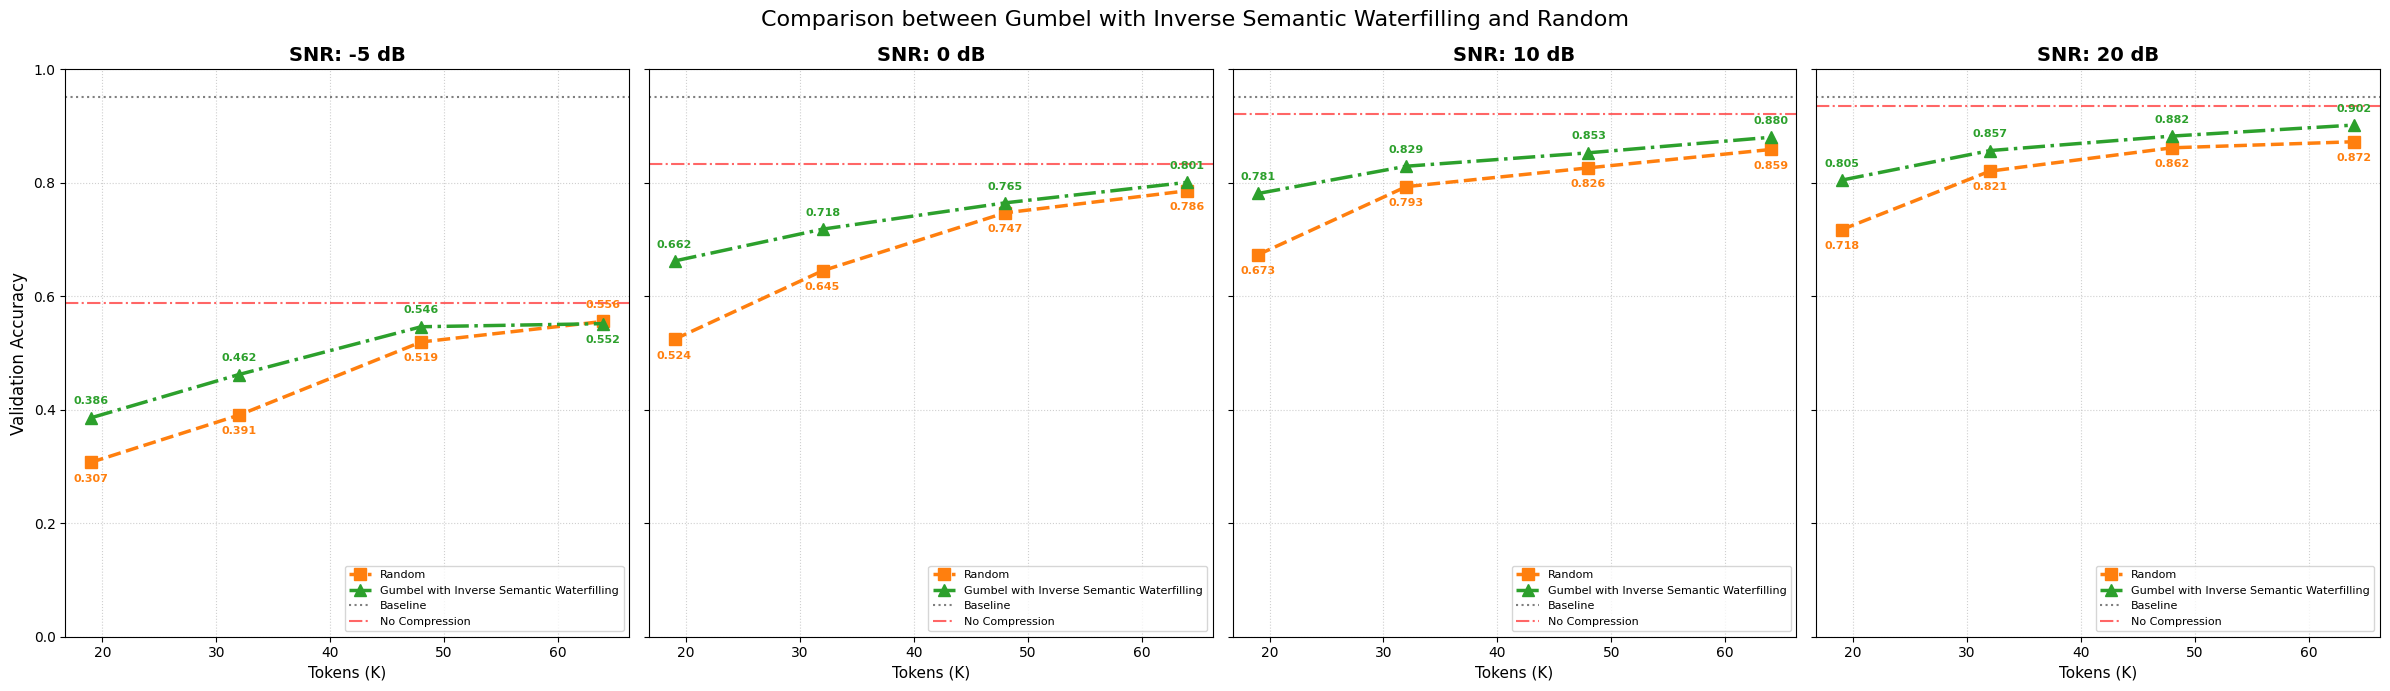

In [18]:
import json
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# =====================================================================
# CONFIGURAZIONE STRATEGIA
# =====================================================================
MODE = "final"       # Opzioni: "best" (usa best_results.json), "final" (usa final_results.json + strategy)
STRATEGY = "average" # Opzioni: "average", "last", "max_noise", "min_noise", "snr_index"
SNR_INDEX_VAL = 0    # Usato solo se STRATEGY == "snr_index"
VERSION = "split_1"

WORKSPACE_ROOT = Path(r"c:\Users\matteo\OneDrive - uniroma1.it\Documenti\data science\Tesi\proj_locale")

DATA_ROOTS = {
    "Random": WORKSPACE_ROOT / "results" / "S5_ROB_MIMO_S_RANDOM" / "flowers"/ VERSION ,
    "Gumbel with Inverse Semantic Waterfilling": WORKSPACE_ROOT / "results" / "S5_ROB_MIMO_S" / "flowers" / VERSION
}

BASELINE_S3 = WORKSPACE_ROOT / "results" / "S3_ROB_MIMO" / "flowers_102" / VERSION
BASELINE_S1 = WORKSPACE_ROOT / "results" / "S1_CLEAN" / "flowers"

# =====================================================================
# FUNZIONI DI SUPPORTO
# =====================================================================
def _load_json(path: Path) -> dict:
    if not path.exists(): return None
    try: return json.loads(path.read_text(encoding="utf-8"))
    except: return None

def extract_compression(folder_path: Path):
    match = re.search(r"compression=(\d+)", folder_path.name)
    return int(match.group(1)) if match else None

def get_baseline_curve(data: dict):
    """Estrae la curva dai file dei baseline (best_training_results.json)."""
    if not data: return {}
    if "best_val_accuracy" in data:
        curve = data["best_val_accuracy"]
        return {float(k): float(v) for k, v in curve.items()} if isinstance(curve, dict) else {"clean": float(curve)}
    return {}

def select_epoch_curve(data: dict, strategy: str, snr_idx: int = 0):
    """Estrae la curva da final_training_results.json secondo la strategia selezionata."""
    vals = data.get("Val accuracies", [])
    if not vals or not isinstance(vals[0], dict): return {}

    selected_idx = -1
    
    if strategy == "last":
        selected_idx = len(vals) - 1
    elif strategy == "average":
        means = [np.mean(list(epoch_dict.values())) for epoch_dict in vals]
        selected_idx = np.argmax(means)
    elif strategy == "max_noise":
        sorted_keys = sorted(vals[0].keys(), key=float)
        target_k = sorted_keys[0]
        pts = [epoch_dict[target_k] for epoch_dict in vals]
        selected_idx = np.argmax(pts)
    elif strategy == "min_noise":
        sorted_keys = sorted(vals[0].keys(), key=float)
        target_k = sorted_keys[-1]
        pts = [epoch_dict[target_k] for epoch_dict in vals]
        selected_idx = np.argmax(pts)
    elif strategy == "snr_index":
        sorted_keys = sorted(vals[0].keys(), key=float)
        target_k = sorted_keys[min(snr_idx, len(sorted_keys)-1)]
        pts = [epoch_dict[target_k] for epoch_dict in vals]
        selected_idx = np.argmax(pts)
    
    if selected_idx != -1:
        return {float(k): float(v) for k, v in vals[selected_idx].items()}
    return {}

def get_data_curve(res_path: Path):
    data = _load_json(res_path)
    if not data: return {}
    
    # Se MODE è best, usiamo il formato best_val_accuracy
    if MODE == "best" and "best_val_accuracy" in data:
        curve = data["best_val_accuracy"]
        return {float(k): float(v) for k, v in curve.items()} if isinstance(curve, dict) else {"clean": float(curve)}
    
    # Altrimenti usiamo la strategia sulle epoche
    return select_epoch_curve(data, STRATEGY, SNR_INDEX_VAL)

# Discovery Dati
snr_mapping = defaultdict(lambda: defaultdict(list))
data_by_k = defaultdict(lambda: defaultdict(dict))

for method_name, root in DATA_ROOTS.items():
    if not root.exists(): continue
    for folder in root.iterdir():
        if not folder.is_dir(): continue
        comp_val = extract_compression(folder)
        if comp_val is None: continue
        
        filename = "best_training_results.json" if MODE == "best" else "final_training_results.json"
        res_file = folder / filename
        if not res_file.exists(): 
             res_file = folder / ("final_training_results.json" if MODE == "best" else "best_training_results.json")
        
        curve = get_data_curve(res_file)
        for snr, acc in curve.items():
            if snr != "clean":
                snr_mapping[snr][method_name].append((comp_val, acc))
                data_by_k[snr][comp_val][method_name] = acc

# Caricamento Baseline (sempre tramite best_results)
s3_data = get_baseline_curve(_load_json(BASELINE_S3 / "best_training_results.json"))
s1_val = _load_json(BASELINE_S1 / "best_training_results.json").get("best_val_accuracy")

# =====================================================================
# PLOTTING (4 Grafici Orizzontali)
# =====================================================================
sorted_snrs = sorted(snr_mapping.keys())
n_snrs = len(sorted_snrs)
fig, axes = plt.subplots(1, n_snrs, figsize=(6 * n_snrs, 7), sharey=True)
if n_snrs == 1: axes = [axes]

method_styles = {
    "Random":   {"color": "tab:orange", "style": "--s"},
    "Gumbel with Inverse Semantic Waterfilling": {"color": "tab:green",  "style": "-.^"}
}
offset_base = 0.020

for i, snr in enumerate(sorted_snrs):
    ax = axes[i]
    for method, cfg in method_styles.items():
        points = snr_mapping[snr][method]
        if points:
            points.sort()
            x, y = zip(*points)
            ax.plot(x, y, cfg["style"], label=method, linewidth=2.5, markersize=8, color=cfg["color"])

    for k in sorted(data_by_k[snr].keys()):
        k_results = data_by_k[snr][k]
        sorted_methods = sorted(k_results.items(), key=lambda x: x[1], reverse=True)
        num_methods = len(sorted_methods)
        for idx, (m_name, acc) in enumerate(sorted_methods):
            if idx == 0: va, y_off = 'bottom', offset_base
            elif idx == num_methods - 1 and num_methods > 1: va, y_off = 'top', -offset_base
            else: continue
            ax.text(k, acc + y_off, f"{acc:.3f}", ha='center', va=va, color=method_styles[m_name]["color"], fontweight='bold', fontsize=8)

    if s1_val: ax.axhline(y=s1_val, color='black', linestyle=':', alpha=0.5, label="Baseline")
    if snr in s3_data: ax.axhline(y=s3_data[snr], color='red', linestyle='-.', alpha=0.6, label="No Compression")

    ax.set_title(f"SNR: {int(snr) if snr == int(snr) else snr} dB", fontsize=14, fontweight='bold')
    ax.set_xlabel("Tokens (K)", fontsize=11)
    if i == 0: ax.set_ylabel("Validation Accuracy", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle(f"Comparison between Gumbel with Inverse Semantic Waterfilling and Random", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


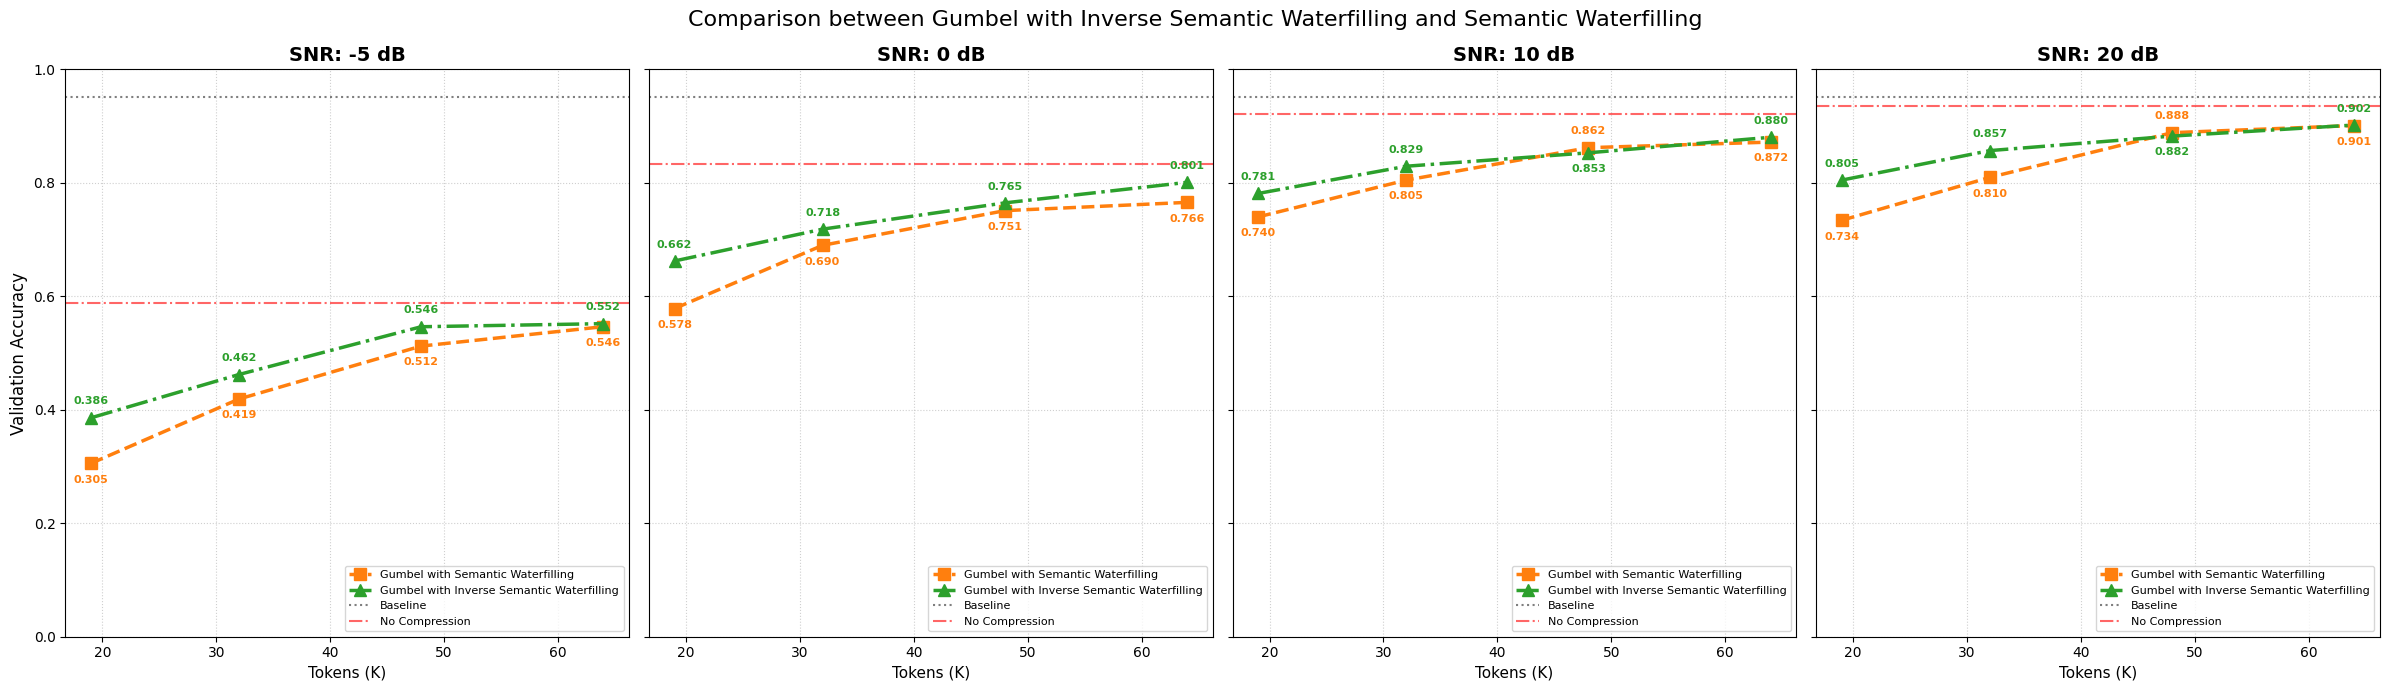

In [22]:
import json
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# =====================================================================
# CONFIGURAZIONE STRATEGIA
# =====================================================================
MODE = "final"       # Opzioni: "best" (usa best_results.json), "final" (usa final_results.json + strategy)
STRATEGY = "average" # Opzioni: "average", "last", "max_noise", "min_noise", "snr_index"
SNR_INDEX_VAL = 0    # Usato solo se STRATEGY == "snr_index"
VERSION = "split_1"

WORKSPACE_ROOT = Path(r"c:\Users\matteo\OneDrive - uniroma1.it\Documenti\data science\Tesi\proj_locale")

DATA_ROOTS = {
    "Gumbel with Semantic Waterfilling": WORKSPACE_ROOT / "results" / "S5_ROB_MIMO_S" / "flowers" / "split_1.2" ,
    "Gumbel with Inverse Semantic Waterfilling": WORKSPACE_ROOT / "results" / "S5_ROB_MIMO_S" / "flowers" / VERSION
}

BASELINE_S3 = WORKSPACE_ROOT / "results" / "S3_ROB_MIMO" / "flowers_102" / VERSION
BASELINE_S1 = WORKSPACE_ROOT / "results" / "S1_CLEAN" / "flowers"

# =====================================================================
# FUNZIONI DI SUPPORTO
# =====================================================================
def _load_json(path: Path) -> dict:
    if not path.exists(): return None
    try: return json.loads(path.read_text(encoding="utf-8"))
    except: return None

def extract_compression(folder_path: Path):
    match = re.search(r"compression=(\d+)", folder_path.name)
    return int(match.group(1)) if match else None

def get_baseline_curve(data: dict):
    """Estrae la curva dai file dei baseline (best_training_results.json)."""
    if not data: return {}
    if "best_val_accuracy" in data:
        curve = data["best_val_accuracy"]
        return {float(k): float(v) for k, v in curve.items()} if isinstance(curve, dict) else {"clean": float(curve)}
    return {}

def select_epoch_curve(data: dict, strategy: str, snr_idx: int = 0):
    """Estrae la curva da final_training_results.json secondo la strategia selezionata."""
    vals = data.get("Val accuracies", [])
    if not vals or not isinstance(vals[0], dict): return {}

    selected_idx = -1
    
    if strategy == "last":
        selected_idx = len(vals) - 1
    elif strategy == "average":
        means = [np.mean(list(epoch_dict.values())) for epoch_dict in vals]
        selected_idx = np.argmax(means)
    elif strategy == "max_noise":
        sorted_keys = sorted(vals[0].keys(), key=float)
        target_k = sorted_keys[0]
        pts = [epoch_dict[target_k] for epoch_dict in vals]
        selected_idx = np.argmax(pts)
    elif strategy == "min_noise":
        sorted_keys = sorted(vals[0].keys(), key=float)
        target_k = sorted_keys[-1]
        pts = [epoch_dict[target_k] for epoch_dict in vals]
        selected_idx = np.argmax(pts)
    elif strategy == "snr_index":
        sorted_keys = sorted(vals[0].keys(), key=float)
        target_k = sorted_keys[min(snr_idx, len(sorted_keys)-1)]
        pts = [epoch_dict[target_k] for epoch_dict in vals]
        selected_idx = np.argmax(pts)
    
    if selected_idx != -1:
        return {float(k): float(v) for k, v in vals[selected_idx].items()}
    return {}

def get_data_curve(res_path: Path):
    data = _load_json(res_path)
    if not data: return {}
    
    # Se MODE è best, usiamo il formato best_val_accuracy
    if MODE == "best" and "best_val_accuracy" in data:
        curve = data["best_val_accuracy"]
        return {float(k): float(v) for k, v in curve.items()} if isinstance(curve, dict) else {"clean": float(curve)}
    
    # Altrimenti usiamo la strategia sulle epoche
    return select_epoch_curve(data, STRATEGY, SNR_INDEX_VAL)

# Discovery Dati
snr_mapping = defaultdict(lambda: defaultdict(list))
data_by_k = defaultdict(lambda: defaultdict(dict))

for method_name, root in DATA_ROOTS.items():
    if not root.exists(): continue
    for folder in root.iterdir():
        if not folder.is_dir(): continue
        comp_val = extract_compression(folder)
        if comp_val is None: continue
        
        filename = "best_training_results.json" if MODE == "best" else "final_training_results.json"
        res_file = folder / filename
        if not res_file.exists(): 
             res_file = folder / ("final_training_results.json" if MODE == "best" else "best_training_results.json")
        
        curve = get_data_curve(res_file)
        for snr, acc in curve.items():
            if snr != "clean":
                snr_mapping[snr][method_name].append((comp_val, acc))
                data_by_k[snr][comp_val][method_name] = acc

# Caricamento Baseline (sempre tramite best_results)
s3_data = get_baseline_curve(_load_json(BASELINE_S3 / "best_training_results.json"))
s1_val = _load_json(BASELINE_S1 / "best_training_results.json").get("best_val_accuracy")

# =====================================================================
# PLOTTING (4 Grafici Orizzontali)
# =====================================================================
sorted_snrs = sorted(snr_mapping.keys())
n_snrs = len(sorted_snrs)
fig, axes = plt.subplots(1, n_snrs, figsize=(6 * n_snrs, 7), sharey=True)
if n_snrs == 1: axes = [axes]

method_styles = {
    "Gumbel with Semantic Waterfilling":   {"color": "tab:orange", "style": "--s"},
    "Gumbel with Inverse Semantic Waterfilling": {"color": "tab:green",  "style": "-.^"}
}
offset_base = 0.020

for i, snr in enumerate(sorted_snrs):
    ax = axes[i]
    for method, cfg in method_styles.items():
        points = snr_mapping[snr][method]
        if points:
            points.sort()
            x, y = zip(*points)
            ax.plot(x, y, cfg["style"], label=method, linewidth=2.5, markersize=8, color=cfg["color"])

    for k in sorted(data_by_k[snr].keys()):
        k_results = data_by_k[snr][k]
        sorted_methods = sorted(k_results.items(), key=lambda x: x[1], reverse=True)
        num_methods = len(sorted_methods)
        for idx, (m_name, acc) in enumerate(sorted_methods):
            if idx == 0: va, y_off = 'bottom', offset_base
            elif idx == num_methods - 1 and num_methods > 1: va, y_off = 'top', -offset_base
            else: continue
            ax.text(k, acc + y_off, f"{acc:.3f}", ha='center', va=va, color=method_styles[m_name]["color"], fontweight='bold', fontsize=8)

    if s1_val: ax.axhline(y=s1_val, color='black', linestyle=':', alpha=0.5, label="Baseline")
    if snr in s3_data: ax.axhline(y=s3_data[snr], color='red', linestyle='-.', alpha=0.6, label="No Compression")

    ax.set_title(f"SNR: {int(snr) if snr == int(snr) else snr} dB", fontsize=14, fontweight='bold')
    ax.set_xlabel("Tokens (K)", fontsize=11)
    if i == 0: ax.set_ylabel("Validation Accuracy", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle(f"Comparison between Gumbel with Inverse Semantic Waterfilling and Semantic Waterfilling", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


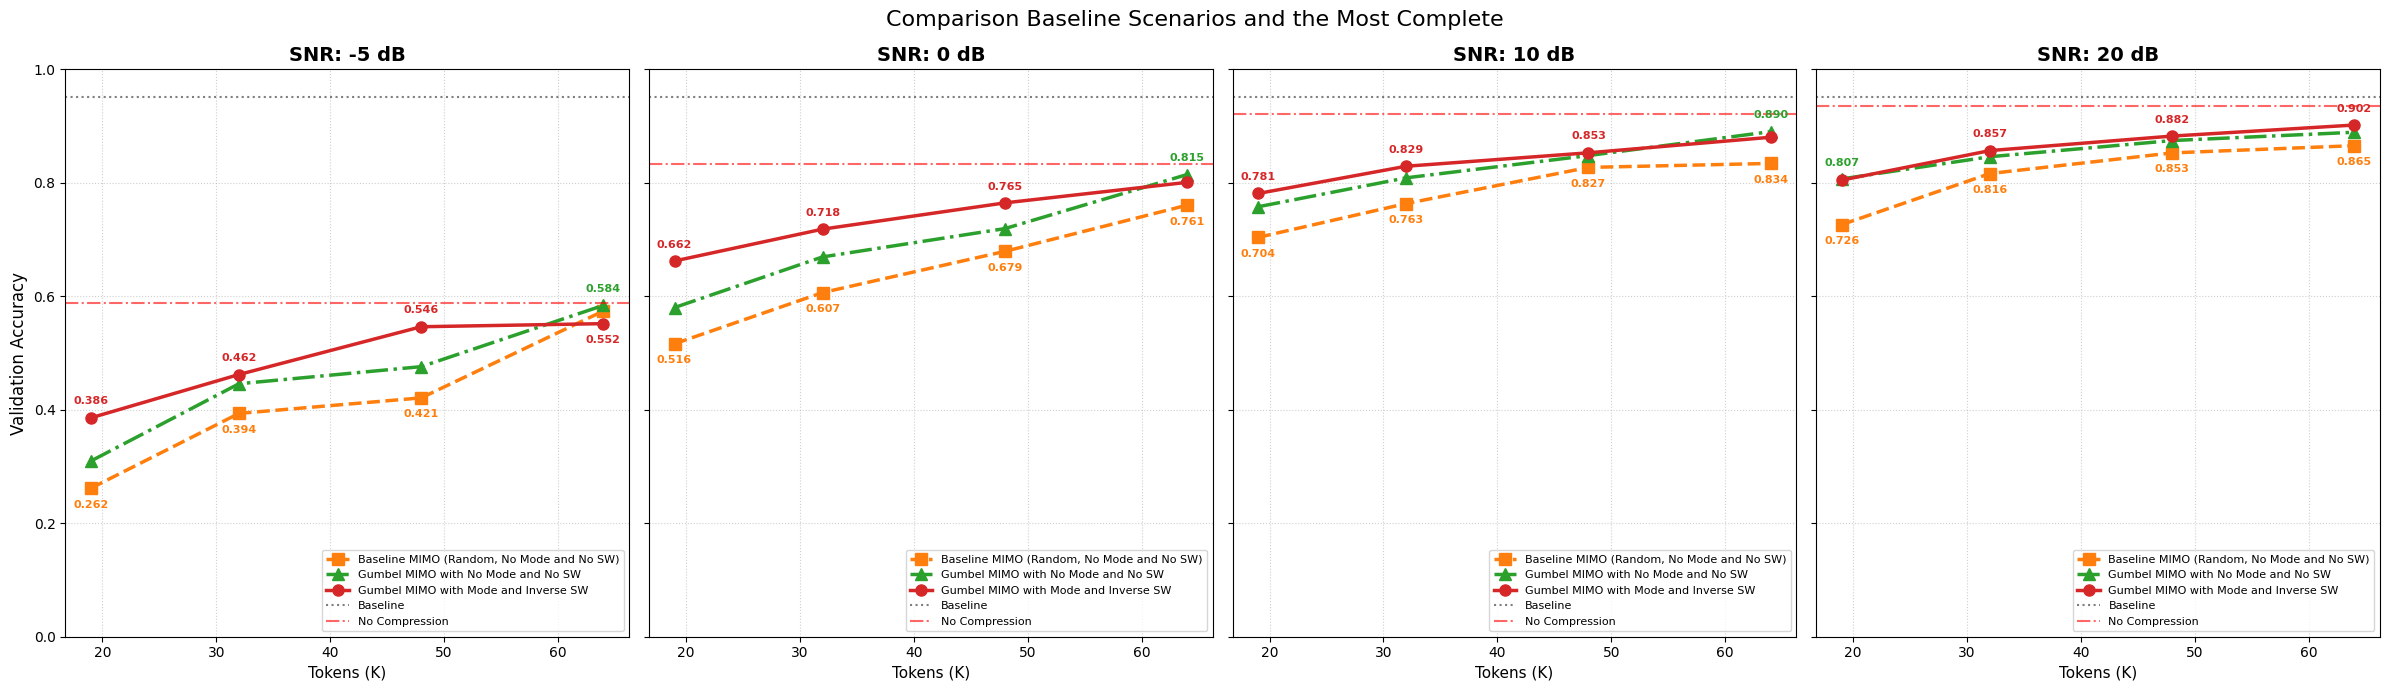

In [4]:
import json
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# =====================================================================
# CONFIGURAZIONE STRATEGIA
# =====================================================================
MODE = "final"       # Opzioni: "best" (usa best_results.json), "final" (usa final_results.json + strategy)
STRATEGY = "average" # Opzioni: "average", "last", "max_noise", "min_noise", "snr_index"
SNR_INDEX_VAL = 0    # Usato solo se STRATEGY == "snr_index"
VERSION = "split_1"

WORKSPACE_ROOT = Path(r"c:\Users\matteo\OneDrive - uniroma1.it\Documenti\data science\Tesi\proj_locale")

DATA_ROOTS = {
    "Baseline MIMO (Random, No Mode and No SW)": WORKSPACE_ROOT / "results" / "S5_ROB_MIMO_S_RANDOM" / "flowers" / "split_1.2" ,
    "Gumbel MIMO with No Mode and No SW": WORKSPACE_ROOT / "results" / "S5_ROB_MIMO_S" / "flowers" / "split_1_No_Mode_No_SW",
    "Gumbel MIMO with Mode and Inverse SW": WORKSPACE_ROOT / "results" / "S5_ROB_MIMO_S" / "flowers" / "split_1"
}

BASELINE_S3 = WORKSPACE_ROOT / "results" / "S3_ROB_MIMO" / "flowers_102" / VERSION
BASELINE_S1 = WORKSPACE_ROOT / "results" / "S1_CLEAN" / "flowers"

# =====================================================================
# FUNZIONI DI SUPPORTO
# =====================================================================
def _load_json(path: Path) -> dict:
    if not path.exists(): return None
    try: return json.loads(path.read_text(encoding="utf-8"))
    except: return None

def extract_compression(folder_path: Path):
    match = re.search(r"compression=(\d+)", folder_path.name)
    return int(match.group(1)) if match else None

def get_baseline_curve(data: dict):
    """Estrae la curva dai file dei baseline (best_training_results.json)."""
    if not data: return {}
    if "best_val_accuracy" in data:
        curve = data["best_val_accuracy"]
        return {float(k): float(v) for k, v in curve.items()} if isinstance(curve, dict) else {"clean": float(curve)}
    return {}

def select_epoch_curve(data: dict, strategy: str, snr_idx: int = 0):
    """Estrae la curva da final_training_results.json secondo la strategia selezionata."""
    vals = data.get("Val accuracies", [])
    if not vals or not isinstance(vals[0], dict): return {}

    selected_idx = -1
    
    if strategy == "last":
        selected_idx = len(vals) - 1
    elif strategy == "average":
        means = [np.mean(list(epoch_dict.values())) for epoch_dict in vals]
        selected_idx = np.argmax(means)
    elif strategy == "max_noise":
        sorted_keys = sorted(vals[0].keys(), key=float)
        target_k = sorted_keys[0]
        pts = [epoch_dict[target_k] for epoch_dict in vals]
        selected_idx = np.argmax(pts)
    elif strategy == "min_noise":
        sorted_keys = sorted(vals[0].keys(), key=float)
        target_k = sorted_keys[-1]
        pts = [epoch_dict[target_k] for epoch_dict in vals]
        selected_idx = np.argmax(pts)
    elif strategy == "snr_index":
        sorted_keys = sorted(vals[0].keys(), key=float)
        target_k = sorted_keys[min(snr_idx, len(sorted_keys)-1)]
        pts = [epoch_dict[target_k] for epoch_dict in vals]
        selected_idx = np.argmax(pts)
    
    if selected_idx != -1:
        return {float(k): float(v) for k, v in vals[selected_idx].items()}
    return {}

def get_data_curve(res_path: Path):
    data = _load_json(res_path)
    if not data: return {}
    
    # Se MODE è best, usiamo il formato best_val_accuracy
    if MODE == "best" and "best_val_accuracy" in data:
        curve = data["best_val_accuracy"]
        return {float(k): float(v) for k, v in curve.items()} if isinstance(curve, dict) else {"clean": float(curve)}
    
    # Altrimenti usiamo la strategia sulle epoche
    return select_epoch_curve(data, STRATEGY, SNR_INDEX_VAL)

# Discovery Dati
snr_mapping = defaultdict(lambda: defaultdict(list))
data_by_k = defaultdict(lambda: defaultdict(dict))

for method_name, root in DATA_ROOTS.items():
    if not root.exists(): continue
    for folder in root.iterdir():
        if not folder.is_dir(): continue
        comp_val = extract_compression(folder)
        if comp_val is None: continue
        
        filename = "best_training_results.json" if MODE == "best" else "final_training_results.json"
        res_file = folder / filename
        if not res_file.exists(): 
             res_file = folder / ("final_training_results.json" if MODE == "best" else "best_training_results.json")
        
        curve = get_data_curve(res_file)
        for snr, acc in curve.items():
            if snr != "clean":
                snr_mapping[snr][method_name].append((comp_val, acc))
                data_by_k[snr][comp_val][method_name] = acc

# Caricamento Baseline (sempre tramite best_results)
s3_data = get_baseline_curve(_load_json(BASELINE_S3 / "best_training_results.json"))
s1_val = _load_json(BASELINE_S1 / "best_training_results.json").get("best_val_accuracy")

# =====================================================================
# PLOTTING (4 Grafici Orizzontali)
# =====================================================================
sorted_snrs = sorted(snr_mapping.keys())
n_snrs = len(sorted_snrs)
fig, axes = plt.subplots(1, n_snrs, figsize=(6 * n_snrs, 7), sharey=True)
if n_snrs == 1: axes = [axes]

method_styles = {
    "Baseline MIMO (Random, No Mode and No SW)":   {"color": "tab:orange", "style": "--s"},
    "Gumbel MIMO with No Mode and No SW": {"color": "tab:green",  "style": "-.^"},
    "Gumbel MIMO with Mode and Inverse SW": {"color": "tab:red",  "style": "-o"}
}
offset_base = 0.020

for i, snr in enumerate(sorted_snrs):
    ax = axes[i]
    for method, cfg in method_styles.items():
        points = snr_mapping[snr][method]
        if points:
            points.sort()
            x, y = zip(*points)
            ax.plot(x, y, cfg["style"], label=method, linewidth=2.5, markersize=8, color=cfg["color"])

    for k in sorted(data_by_k[snr].keys()):
        k_results = data_by_k[snr][k]
        sorted_methods = sorted(k_results.items(), key=lambda x: x[1], reverse=True)
        num_methods = len(sorted_methods)
        for idx, (m_name, acc) in enumerate(sorted_methods):
            if idx == 0: va, y_off = 'bottom', offset_base
            elif idx == num_methods - 1 and num_methods > 1: va, y_off = 'top', -offset_base
            else: continue
            ax.text(k, acc + y_off, f"{acc:.3f}", ha='center', va=va, color=method_styles[m_name]["color"], fontweight='bold', fontsize=8)

    if s1_val: ax.axhline(y=s1_val, color='black', linestyle=':', alpha=0.5, label="Baseline")
    if snr in s3_data: ax.axhline(y=s3_data[snr], color='red', linestyle='-.', alpha=0.6, label="No Compression")

    ax.set_title(f"SNR: {int(snr) if snr == int(snr) else snr} dB", fontsize=14, fontweight='bold')
    ax.set_xlabel("Tokens (K)", fontsize=11)
    if i == 0: ax.set_ylabel("Validation Accuracy", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle(f"Comparison Baseline Scenarios and the Most Complete", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()
